# Dataset Overview

This notebook is the first section of the **Phase 3 Exploratory Data Analysis (EDA)**
for the Delhi AQI / GRAP project.

**Scope of this section.** We describe only the *shape and structure* of the
analytical dataset: counts, ranges, data types, and missingness. The goal is to
understand what the dataset contains before any analysis begins.

**Deliberately out of scope here.** No statistics, no averages, no comparisons
between stations or GRAP stages, and no interpretation of pollution. Those belong
to later sections of the EDA.

> The notebook assumes it is run from the `notebooks/` folder, so the data path
> below starts with `../`.

In [1]:
import pandas as pd

# Path to the merged analytical dataset built in Phase 2.
# This assumes the notebook is run from the 'notebooks/' folder.
data_path = '../data/processed/station_daily_grap.csv'

# Load the whole dataset into a DataFrame called df.
df = pd.read_csv(data_path)

# Look at the first five rows to see the overall structure.
df.head()

,station_id,station_name,date,year,pm25_ugm3,pm10_ugm3,air_temp_c,rh_pct,wind_speed_ms,wind_dir_deg,season,grap_stage,is_event_day,days_since_last_change,days_until_next_change,source_file
0,anand_vihar,Anand Vihar,2022-01-01,2022,393.56,598.82,13.97,75.32,0.32,230.10,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"
1,anand_vihar,Anand Vihar,2022-01-02,2022,424.81,598.95,14.33,75.32,0.32,230.36,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"
2,anand_vihar,Anand Vihar,2022-01-03,2022,375.52,636.12,14.79,72.44,0.35,223.51,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"
3,anand_vihar,Anand Vihar,2022-01-04,2022,291.86,564.58,16.14,66.95,0.31,209.49,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"
4,anand_vihar,Anand Vihar,2022-01-05,2022,353.05,449.37,14.45,86.60,0.89,138.08,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"


**What this does.** Imports pandas and loads the merged Phase 2 dataset
(`station_daily_grap.csv`) into a DataFrame named `df`. `df.head()` prints the
first five rows.

**Why it matters.** Every later step reads from this single DataFrame, so we first
confirm the file loads and that the columns look as expected.

**How to read it.** Each row is one **station on one day**. Scan the first rows to
confirm you can see a station id, a date, the pollutant and weather readings, and
the GRAP columns side by side.

In [2]:
# df.shape returns (number_of_rows, number_of_columns).
total_observations = df.shape[0]
number_of_variables = df.shape[1]

# Put the two numbers into a small, readable table.
size_overview = pd.DataFrame({
    'Metric': ['Total observations (rows)', 'Number of variables (columns)'],
    'Value': [total_observations, number_of_variables]
})
size_overview

,Metric,Value
0,Total observations (rows),5840
1,Number of variables (columns),16


**What this does.** Reads `df.shape` for the row and column counts and places them
in a small table.

**Why it matters.** The row count is how many observations we have to work with;
the column count is how many variables describe each observation.

**How to read it.** The dataset is organised as *stations × days*, so the row
count should equal the number of stations multiplied by the number of days
covered. The column count is the number of fields available for analysis.

In [3]:
# nunique() counts how many different station ids appear in the data.
number_of_stations = df['station_id'].nunique()
print('Number of unique stations:', number_of_stations)

# List each station once, with its id and human-readable name.
station_list = df[['station_id', 'station_name']].drop_duplicates()
station_list = station_list.reset_index(drop=True)
station_list

Number of unique stations: 8


,station_id,station_name
0,anand_vihar,Anand Vihar
1,bawana,Bawana
2,jawaharlal_nehru_stadium,Jawaharlal Nehru Stadium
3,najafgarh,Najafgarh
4,narela,Narela
5,okhla_phase_2,Okhla Phase-2
6,punjabi_bagh,Punjabi Bagh
7,r_k_puram,R K Puram


**What this does.** Counts the distinct station ids and lists each station once
with its readable name.

**Why it matters.** The number of stations sets the geographic breadth of the
study. Knowing exactly which stations are present prevents accidentally analysing
the wrong set of locations.

**How to read it.** Confirm the list matches the eight monitoring stations the
project locked in earlier. A missing or extra station here would change the scope
of every downstream comparison.

In [4]:
# Convert the date column from plain text into real dates so we can
# find the earliest and latest day in the dataset.
df['date'] = pd.to_datetime(df['date'])

earliest_date = df['date'].min()
latest_date = df['date'].max()
number_of_years = df['year'].nunique()

date_overview = pd.DataFrame({
    'Metric': ['Earliest date', 'Latest date', 'Number of distinct years'],
    'Value': [earliest_date, latest_date, number_of_years]
})
date_overview

,Metric,Value
0,Earliest date,2022-01-01 00:00:00
1,Latest date,2023-12-31 00:00:00
2,Number of distinct years,2


**What this does.** Converts the `date` text into real dates, then reports the
earliest date, the latest date, and how many distinct calendar years appear.

**Why it matters.** The date range defines the time window of the study, and the
year count tells us how many annual cycles are represented.

**How to read it.** The earliest and latest dates should bracket the full study
period. The number of distinct years indicates whether year-to-year views are even
possible — two years allows a same-season comparison, not a long-term trend.

In [5]:
# is_event_day equals 1 on days when a GRAP order changed the stage.
# Because every date is repeated once per station, we keep the unique dates.
event_rows = df[df['is_event_day'] == 1]
number_of_grap_events = event_rows['date'].nunique()
print('Number of GRAP events available:', number_of_grap_events)

# Show the distinct event dates in order.
event_dates = event_rows['date'].drop_duplicates().sort_values()
event_dates = event_dates.reset_index(drop=True)
event_dates

Number of GRAP events available: 9


0   2022-10-05
1   2022-10-19
2   2022-10-29
3   2022-11-03
4   2022-11-06
5   2022-11-14
6   2022-12-04
7   2022-12-07
8   2022-12-30
Name: date, dtype: datetime64[ns]

**What this does.** Filters to rows flagged as event days, then counts the unique
event dates and lists them.

**Why it matters.** GRAP events are the policy anchors of the whole project. The
number of available events limits how many policy changes can eventually be
studied.

**How to read it.** Each date here is a day on which a GRAP order changed the
stage. A small number of events means later event-based views will rest on a
limited set of dates — useful context to keep in mind.

In [6]:
# isnull() marks every empty cell as True; sum() counts those per column.
missing_count = df.isnull().sum()

# Express the same thing as a percentage of all rows.
missing_pct = (df.isnull().sum() / len(df)) * 100

# Combine both into one clean table.
missing_overview = pd.DataFrame({
    'Missing count': missing_count,
    'Missing %': missing_pct.round(2)
})

# Show the columns with the most missing values first.
missing_overview = missing_overview.sort_values(by='Missing count', ascending=False)
missing_overview

,Missing count,Missing %
days_until_next_change,5120,87.67
days_since_last_change,4664,79.86
season,3424,58.63
pm10_ugm3,119,2.04
pm25_ugm3,77,1.32
wind_speed_ms,69,1.18
wind_dir_deg,69,1.18
rh_pct,68,1.16
air_temp_c,68,1.16
station_name,0,0.00


**What this does.** Counts empty cells in every column and also shows them as a
percentage of all rows, sorted from most to least missing.

**Why it matters.** Missingness tells us how complete each variable is. A field
that is largely empty cannot support the same analysis as a nearly complete one.

**How to read it.** Distinguish two kinds of blanks. Empty *measurement* columns
(`pm25_ugm3`, `pm10_ugm3`, and the weather fields) are genuine data gaps. By
contrast, `season`, `days_since_last_change`, and `days_until_next_change` are
blank **by design** — off-season days have no season, and days outside an event
run have no countdown. Read those structural blanks differently from measurement
gaps.

In [7]:
# dtypes reports the storage type pandas chose for each column.
dtype_overview = pd.DataFrame({
    'Column': df.columns,
    'Data type': df.dtypes.astype(str).values
})
dtype_overview = dtype_overview.reset_index(drop=True)
dtype_overview

,Column,Data type
0,station_id,object
1,station_name,object
2,date,datetime64[ns]
3,year,int64
4,pm25_ugm3,float64
5,pm10_ugm3,float64
6,air_temp_c,float64
7,rh_pct,float64
8,wind_speed_ms,float64
9,wind_dir_deg,float64


**What this does.** Lists the data type pandas assigned to each column.

**Why it matters.** The type controls what operations are valid: numbers can be
averaged, while text and category-like fields are grouped and counted. A column
stored as the wrong type is a common source of errors later.

**How to read it.** Check that the pollutant and weather columns are numeric
(`float`), that `date` is a datetime after our conversion, and that identifier and
label columns are text (`object`). Anything unexpected here is worth fixing before
analysis.

In [8]:
# These columns act like labels or small fixed sets, not measurements.
categorical_columns = [
    'station_id',
    'station_name',
    'year',
    'season',
    'grap_stage',
    'is_event_day',
    'source_file'
]

# Count how many different values each of these columns takes.
unique_value_counts = []
for column_name in categorical_columns:
    unique_value_counts.append(df[column_name].nunique())

unique_overview = pd.DataFrame({
    'Column': categorical_columns,
    'Number of unique values': unique_value_counts
})
unique_overview

,Column,Number of unique values
0,station_id,8
1,station_name,8
2,year,2
3,season,3
4,grap_stage,5
5,is_event_day,2
6,source_file,16


**What this does.** For each label-like column, counts how many distinct values it
contains.

**Why it matters.** The number of categories tells us how a column can be used —
for example, how many groups a future breakdown would produce.

**How to read it.** Low-cardinality columns (a few values) are natural grouping
keys; high-cardinality label columns such as `source_file` mainly serve as
provenance rather than as grouping dimensions.

In [9]:
# For the columns with only a handful of categories, list every value.
small_categorical_columns = ['year', 'season', 'grap_stage', 'is_event_day']

for column_name in small_categorical_columns:
    values = df[column_name].unique()
    print(column_name, '->', values)

year -> [2022 2023]
season -> ['2021-22' nan '2022-23' '2023-24']
grap_stage -> [0 1 2 3 4]
is_event_day -> [0 1]


**What this does.** Prints the actual set of values for the smallest categorical
columns.

**Why it matters.** Seeing the real values confirms our assumptions about how the
data is coded — for instance, that GRAP stages run 0–4 and that the event flag is
only 0 or 1.

**How to read it.** Verify the years are the two expected calendar years, the GRAP
stages are the whole-number codes 0 through 4, and note that `season` includes a
blank (`NaN`) value for the off-season days seen in the missingness table above.

## Questions Raised

Inspecting the metadata above naturally raises the following analytical questions.
They are recorded here as a to-do list for later sections — **they are not
answered in this Dataset Overview.**

1. Which station has the highest average PM2.5, and which has the lowest?
2. Does the amount of missing data vary from one station to another?
3. Are some variables (for example wind speed or humidity) missing more often than
   PM2.5 or PM10?
4. Is missingness concentrated in particular months, seasons, or years?
5. Does PM2.5 appear to follow a seasonal pattern across the year?
6. How many days fall under each GRAP stage (0–4)?
7. Are the two years (2022 and 2023) comparable in terms of data completeness?
8. Do PM2.5 and PM10 tend to move together, or do they diverge at some stations?
9. How do the off-season days (`season` = blank) differ in coverage from in-season
   days?
10. Around the nine GRAP event dates, is there enough surrounding data at every
    station to support an event-window view?

*End of the Dataset Overview section.*

# Data Quality Assessment

Before any analysis, we check how trustworthy the dataset is. This section looks
only at **data quality**: where values are missing, whether any values are
physically impossible, and whether the dataset keeps its intended
one-row-per-station-per-day structure.

As in the previous section, we only *describe and count*. We do not clean, impute,
drop, or interpret anything here — every check simply reports what it finds. The
DataFrame `df` was loaded in the Dataset Overview section above and is reused
unchanged.

## 1. Missing Values by Variable

We start with the simplest completeness view: how many values are missing in each
column, and what share of the dataset that represents.

In [10]:
# isnull() marks each empty cell as True; sum() counts those per column.
missing_count = df.isnull().sum()

# Convert the count into a percentage of all rows in the dataset.
total_rows = len(df)
missing_percentage = (missing_count / total_rows) * 100

# Build a clean table with one row per variable.
missing_by_variable = pd.DataFrame({
    'Variable': df.columns,
    'Missing Count': missing_count.values,
    'Missing Percentage': missing_percentage.values.round(2)
})

# Sort from the highest missing percentage to the lowest.
missing_by_variable = missing_by_variable.sort_values(
    by='Missing Percentage', ascending=False
)
missing_by_variable = missing_by_variable.reset_index(drop=True)
missing_by_variable

,Variable,Missing Count,Missing Percentage
0,days_until_next_change,5120,87.67
1,days_since_last_change,4664,79.86
2,season,3424,58.63
3,pm10_ugm3,119,2.04
4,pm25_ugm3,77,1.32
5,wind_speed_ms,69,1.18
6,wind_dir_deg,69,1.18
7,rh_pct,68,1.16
8,air_temp_c,68,1.16
9,station_name,0,0.00


**What this table shows.** For every column it lists how many cells are empty
(`Missing Count`) and what fraction of all rows that is (`Missing Percentage`),
with the least-complete variables at the top.

**Why analysts inspect missing values first.** Completeness decides what is even
possible later. A variable that is mostly empty cannot support the same work as a
nearly complete one, and unnoticed gaps can quietly distort any figure computed
from that column. Checking missingness first tells us which variables are
dependable.

**Why the percentage is more useful than the count.** A raw count depends on how
big the dataset is — 500 missing rows means very different things in a 1,000-row
table versus a 5,840-row table. The percentage is comparable across variables (and
across datasets) and states directly what fraction of the data is unavailable.

*Reminder from the Dataset Overview:* `season`, `days_since_last_change`, and
`days_until_next_change` are blank **by design**, so their missingness here is
structural rather than a data-collection gap.

## 2. Missing Values by Station

Next we ask whether missing measurements are spread evenly across stations or
concentrated at particular ones. We count missing values of the six measured
variables for each station.

In [11]:
# The six measured variables we care about for data quality.
measurement_columns = [
    'pm25_ugm3',
    'pm10_ugm3',
    'air_temp_c',
    'rh_pct',
    'wind_speed_ms',
    'wind_dir_deg'
]

# Readable labels for the output table.
friendly_names = {
    'pm25_ugm3': 'Missing PM2.5',
    'pm10_ugm3': 'Missing PM10',
    'air_temp_c': 'Missing Temperature',
    'rh_pct': 'Missing Humidity',
    'wind_speed_ms': 'Missing Wind Speed',
    'wind_dir_deg': 'Missing Wind Direction'
}

# Build one row of results per station.
station_rows = []
station_names = df['station_name'].unique()

for station in station_names:
    # Keep only the rows belonging to this station.
    station_data = df[df['station_name'] == station]

    # Describe this station in a small dictionary.
    result = {}
    result['Station'] = station
    result['Total observations'] = len(station_data)

    # Count missing values for each measured variable.
    for column_name in measurement_columns:
        missing_here = station_data[column_name].isnull().sum()
        label = friendly_names[column_name]
        result[label] = missing_here

    station_rows.append(result)

# Turn the list of dictionaries into a table.
missing_by_station = pd.DataFrame(station_rows)
missing_by_station

,Station,Total observations,Missing PM2.5,Missing PM10,Missing Temperature,Missing Humidity,Missing Wind Speed,Missing Wind Direction
0,Anand Vihar,730,10,13,11,11,11,11
1,Bawana,730,10,8,6,6,6,6
2,Jawaharlal Nehru Stadium,730,19,58,16,16,16,16
3,Najafgarh,730,9,9,10,10,11,11
4,Narela,730,10,7,7,7,7,7
5,Okhla Phase-2,730,6,7,6,6,6,6
6,Punjabi Bagh,730,7,8,6,6,6,6
7,R K Puram,730,6,9,6,6,6,6


**What the code does.** For each station it keeps only that station's rows, counts
the total observations, and then counts how many values are missing for each of the
six measured variables.

**Why it matters.** Missingness that is **concentrated at one station** usually
points to a local cause — a faulty or offline sensor, maintenance downtime, or a
calibration issue at that single monitoring site. That is a very different problem
from missingness spread evenly across every station, which would suggest a
city-wide or dataset-wide collection issue.

**How an analyst interprets it.** Scan each column for a station whose missing
count stands out from the others. A station that is missing far more of one
variable can often be treated as a localised instrument problem, and may need to be
handled separately, rather than being read as evidence that the whole city's data
is unreliable.

## 3. Missing Values by Year

We now group the same measured variables by calendar year to see whether the two
years are equally complete.

In [12]:
# Build one row of results per year (reusing the lists from Section 2).
year_rows = []
year_values = df['year'].unique()

for year_value in year_values:
    # Keep only the rows from this year.
    year_data = df[df['year'] == year_value]

    result = {}
    result['Year'] = year_value
    result['Total observations'] = len(year_data)

    # Count missing values for each measured variable in this year.
    for column_name in measurement_columns:
        missing_here = year_data[column_name].isnull().sum()
        label = friendly_names[column_name]
        result[label] = missing_here

    year_rows.append(result)

missing_by_year = pd.DataFrame(year_rows)
missing_by_year = missing_by_year.sort_values(by='Year').reset_index(drop=True)
missing_by_year

,Year,Total observations,Missing PM2.5,Missing PM10,Missing Temperature,Missing Humidity,Missing Wind Speed,Missing Wind Direction
0,2022,2920,17,15,14,14,14,14
1,2023,2920,60,104,54,54,55,55


**What the code does.** It splits the dataset by year, then counts total
observations and missing values of each measured variable within each year.

**Why comparing yearly completeness matters before comparing yearly pollution.**
Any later year-to-year figure is only as sound as the data underneath it. If one
year has many more gaps than the other, then a difference between the years could
come partly from *unequal completeness* rather than from a real difference in
conditions. Establishing that both years are similarly complete (or noting exactly
where they are not) is a prerequisite for trusting any yearly comparison made
later — which we are **not** doing in this section.

**How an analyst interprets it.** Compare the `Total observations` and the missing
counts between the years. Roughly equal completeness means later yearly views rest
on a level footing; a large imbalance is a caveat to carry forward.

## 4. Impossible Value Checks

Here we test each measured variable against transparent physical limits. Values
outside these limits are impossible and point to recording or sensor errors. We
only **count and report** them — no rows are changed or removed.

In [13]:
# Each rule is written out separately and in plain language.
# A comparison against a NaN (missing) value is treated as False, so missing
# cells are never counted as violations here.
checks = []

# PM2.5 cannot be negative.
count = (df['pm25_ugm3'] < 0).sum()
checks.append({'Rule': 'PM2.5 < 0 (negative concentration)', 'Violations': count})

# PM10 cannot be negative.
count = (df['pm10_ugm3'] < 0).sum()
checks.append({'Rule': 'PM10 < 0 (negative concentration)', 'Violations': count})

# Humidity below 0%.
count = (df['rh_pct'] < 0).sum()
checks.append({'Rule': 'Humidity < 0%', 'Violations': count})

# Humidity above 100%.
count = (df['rh_pct'] > 100).sum()
checks.append({'Rule': 'Humidity > 100%', 'Violations': count})

# Wind speed cannot be negative.
count = (df['wind_speed_ms'] < 0).sum()
checks.append({'Rule': 'Wind Speed < 0', 'Violations': count})

# Temperature below -20 C is implausible for Delhi.
count = (df['air_temp_c'] < -20).sum()
checks.append({'Rule': 'Temperature below -20 C', 'Violations': count})

# Temperature above 60 C is implausible for Delhi.
count = (df['air_temp_c'] > 60).sum()
checks.append({'Rule': 'Temperature above 60 C', 'Violations': count})

# Wind direction must lie between 0 and 360 degrees.
outside_range = (df['wind_dir_deg'] < 0) | (df['wind_dir_deg'] > 360)
count = outside_range.sum()
checks.append({'Rule': 'Wind Direction outside 0-360 degrees', 'Violations': count})

impossible_values = pd.DataFrame(checks)
impossible_values

,Rule,Violations
0,PM2.5 < 0 (negative concentration),0
1,PM10 < 0 (negative concentration),0
2,Humidity < 0%,0
3,Humidity > 100%,0
4,Wind Speed < 0,0
5,Temperature below -20 C,0
6,Temperature above 60 C,0
7,Wind Direction outside 0-360 degrees,0


**What the code does.** It applies one transparent rule at a time, counts how many
rows break each rule, and collects the counts into a summary table. Missing cells
are not counted as violations, and nothing is deleted or altered.

**Why it matters.** A value outside a physical limit (a negative concentration,
humidity above 100%, a wind direction beyond 360 degrees) cannot be real and
signals a recording or sensor error. Finding these is essential before the numbers
are used for anything.

**How an analyst interprets it.** A `Violations` count of `0` means no row broke
that rule. Any non-zero count flags specific rows to **investigate** — not to
silently drop. The rules and their thresholds are stated explicitly so the check is
fully reproducible and easy to adjust.

## 5. Duplicate Observation Check

The dataset is meant to hold exactly one row per station per day. Here we confirm
that grain by looking for any repeated station-and-date combinations.

In [14]:
# Mark every row that shares its (station_id, date) pair with another row.
duplicate_mask = df.duplicated(subset=['station_id', 'date'], keep=False)
observed_duplicates = duplicate_mask.sum()

# The intended grain is unique, so we expect zero duplicates.
expected_duplicates = 0

duplicate_summary = pd.DataFrame({
    'Check': ['Duplicate (station, date) rows'],
    'Expected': [expected_duplicates],
    'Observed': [observed_duplicates]
})
duplicate_summary

,Check,Expected,Observed
0,"Duplicate (station, date) rows",0,0


**What the code does.** It flags any rows that share the same `station_id` and
`date`, counts them, and compares the observed number against the expected number
(zero).

**Why duplicate observations would invalidate later analysis.** The dataset's grain
is one station per day. If a station-day appeared twice, that day would be
**double-counted** in any later grouping, average, or event-window view, quietly
pulling those results toward the duplicated rows. A unique grain is what makes
counts and groupings meaningful.

**How an analyst interprets it.** `Observed` should equal `Expected` (0). If it did
not, the duplicated station-days would need to be traced back to their source
before any analysis could be trusted.

## 6. Data Quality Summary

Finally we gather the results of the checks above into a single factual snapshot.
Each row records what was checked and what was observed — no pass/fail judgement is
implied.

In [15]:
# Pull together the key facts found in the checks above.

# Date coverage: how many unique dates and the span.
number_of_dates = df['date'].nunique()
first_day = str(df['date'].min())[:10]
last_day = str(df['date'].max())[:10]

# Total impossible values across all rules (from Section 4).
total_impossible = impossible_values['Violations'].sum()

# Total missing cells among the six measured variables (from Section 2 lists).
total_measurement_missing = 0
for column_name in measurement_columns:
    total_measurement_missing = total_measurement_missing + df[column_name].isnull().sum()

# Do all stations have the same number of observations?
observations_per_station = df.groupby('station_name')['date'].count()
stations_all_equal = observations_per_station.nunique() == 1

# Build the summary as plain statements of fact.
# The check mark only records that the check was performed, not that it 'passed'.
summary_rows = []
summary_rows.append({
    'Check': 'Date coverage',
    'Performed': '✓',
    'Observation': str(number_of_dates) + ' unique dates (' + first_day + ' to ' + last_day + ')'
})
summary_rows.append({
    'Check': 'Duplicate check',
    'Performed': '✓',
    'Observation': str(observed_duplicates) + ' duplicate (station, date) rows observed'
})
summary_rows.append({
    'Check': 'Impossible values',
    'Performed': '✓',
    'Observation': str(total_impossible) + ' violations across all rules'
})
summary_rows.append({
    'Check': 'Missingness (measured variables)',
    'Performed': '✓',
    'Observation': str(total_measurement_missing) + ' missing cells across the six measured variables'
})
summary_rows.append({
    'Check': 'Station completeness',
    'Performed': '✓',
    'Observation': 'All stations have the same number of observations: ' + str(stations_all_equal)
})

data_quality_summary = pd.DataFrame(summary_rows)
data_quality_summary

,Check,Performed,Observation
0,Date coverage,✓,730 unique dates (2022-01-01 to 2023-12-31)
1,Duplicate check,✓,"0 duplicate (station, date) rows observed"
2,Impossible values,✓,0 violations across all rules
3,Missingness (measured variables),✓,470 missing cells across the six measured vari...
4,Station completeness,✓,All stations have the same number of observati...


**What the code does.** It reuses the numbers computed in the checks above — date
coverage, duplicates, impossible values, total missing measurements, and whether
every station has the same number of rows — and lists them in one table.

**Why it matters.** A single snapshot makes the dataset's quality easy to cite and
to carry forward, so later sections can refer back to exactly what was checked and
what was found.

**How an analyst interprets it.** Read each row as a plain factual observation. The
check mark means only that the check was run; the `Observation` column holds the
number that was found. Nothing here decides whether the data is "good enough" — that
judgement belongs to the analyst in light of the question being asked.

## Questions Raised

The quality assessment naturally raises the following questions. They are recorded
here for later sections and are **not answered now.**

1. Which station contributes the most missing PM10, and the most missing PM2.5?
2. Should missing values eventually be imputed, or left as explicit gaps?
3. Are missing observations clustered on particular dates, or spread evenly through
   time?
4. When a station is missing PM2.5 on a given day, is it usually missing PM10 (and
   the weather variables) on that same day?
5. Is overall completeness higher in one year than the other, and if so, in which
   variables?
6. Are there any dates where all eight stations are missing the same variable at
   once — a possible city-wide outage?
7. Do the impossible-value rules flag any rows, and if so, do those rows come from
   specific stations or specific dates?
8. How should the structurally-blank fields (`season`, the day counters) be handled
   so they are never mistaken for data-quality gaps?
9. Is the level of completeness sufficient to support event-window views around all
   nine GRAP event dates?
10. Which variable is the most complete overall, and is it complete enough to serve
    as a dependable anchor for later work?

*End of the Data Quality Assessment section.*

# Variable Distributions

This section looks at how each numerical variable behaves **on its own**, one
variable at a time.

**Scope of this section.** For every numerical variable we compute standard
summary statistics and look at its shape through histograms and box plots.

**Deliberately out of scope here.** No comparisons between years, no comparisons
between GRAP stages, no comparisons between stations, no statistical testing, no
causal reasoning, and no conclusions about policy effectiveness. Those all require
grouping or comparing, and this section is only about describing single variables
in isolation. The DataFrame `df` was loaded in the Dataset Overview section above
and is reused unchanged.

## Summary Statistics

We start by computing the standard descriptive statistics for every numerical
variable: count, mean, median, standard deviation, minimum, the 25th percentile,
the 75th percentile, and maximum.

In [16]:
# The numerical variables we want to describe.
numeric_columns = [
    'pm25_ugm3',
    'pm10_ugm3',
    'air_temp_c',
    'rh_pct',
    'wind_speed_ms',
    'wind_dir_deg'
]

# Readable labels (with units) for the summary table.
variable_labels = {
    'pm25_ugm3': 'PM2.5 (ug/m3)',
    'pm10_ugm3': 'PM10 (ug/m3)',
    'air_temp_c': 'Temperature (C)',
    'rh_pct': 'Humidity (%)',
    'wind_speed_ms': 'Wind Speed (m/s)',
    'wind_dir_deg': 'Wind Direction (degrees)'
}

# describe() computes count, mean, std, min, 25%, 50%, 75%, and max in one call.
# Missing values are skipped automatically, so 'count' can differ between columns.
summary_statistics = df[numeric_columns].describe().T

# Rename the columns to the plain-English names requested.
# Note: the '50%' column produced by describe() IS the median.
summary_statistics = summary_statistics.rename(columns={
    'count': 'Count',
    'mean': 'Mean',
    '50%': 'Median',
    'std': 'Standard Deviation',
    'min': 'Minimum',
    '25%': '25th Percentile',
    '75%': '75th Percentile',
    'max': 'Maximum'
})

# Put the columns in a clear, fixed order.
summary_statistics = summary_statistics[[
    'Count', 'Mean', 'Median', 'Standard Deviation',
    'Minimum', '25th Percentile', '75th Percentile', 'Maximum'
]]

# Round for readability and use the friendly variable names as row labels.
summary_statistics = summary_statistics.round(2)
summary_statistics.index = [variable_labels[col] for col in summary_statistics.index]
summary_statistics

,Count,Mean,Median,Standard Deviation,Minimum,25th Percentile,75th Percentile,Maximum
PM2.5 (ug/m3),5763.0,106.36,82.18,80.25,5.21,46.10,143.73,541.68
PM10 (ug/m3),5721.0,222.17,203.26,125.51,8.75,121.55,300.67,797.25
Temperature (C),5772.0,25.33,27.13,7.48,7.20,18.94,31.24,46.70
Humidity (%),5772.0,62.76,64.45,13.99,3.93,54.41,72.57,95.36
Wind Speed (m/s),5771.0,0.87,0.77,0.56,0.18,0.50,1.08,7.50
Wind Direction (degrees),5771.0,178.30,179.26,57.42,0.90,143.34,209.71,353.00


**What this code does.** It selects the six numerical variables, calls
`describe()` to compute the eight statistics for each one, renames the columns to
plain English, and rounds the numbers for readability.

**Why analysts generate this output.** A single summary table is the fastest way
to get a first sense of every variable at once, before looking at any plot.

**How to interpret each statistic.**

- **Count** — how many non-missing values the variable has. A lower count than the
  total number of rows means that variable has missing data.
- **Mean** — the arithmetic average of all values: add everything up and divide by
  the count.
- **Median** — the middle value when all observations are sorted from smallest to
  largest (the 50th percentile).
- **Standard Deviation** — a measure of how spread out the values are around the
  mean. A small value means observations sit close to the mean; a large value
  means they are spread widely.
- **Minimum / Maximum** — the smallest and largest values observed.
- **25th Percentile / 75th Percentile** — the value below which 25% (respectively
  75%) of the observations fall. Together they mark the middle 50% of the data.

**Why both mean and median are included.** The mean is sensitive to a few very
large or very small values, while the median is not. Reporting both, side by side,
is how an analyst can tell whether a variable might be affected by extreme values
— without yet deciding whether it is.

**Why standard deviation is useful.** It puts a single number on how tightly or
loosely a variable's values cluster around its mean, which is not visible from the
mean alone.

**Why quartiles matter.** The 25th and 75th percentiles frame the middle half of
the data. Comparing them to the minimum and maximum shows whether the extreme
values are close to the bulk of the data or far away from it.

## Histograms

A histogram groups a variable's values into bins and shows how many observations
fall into each bin. We build one for each of PM2.5, PM10, Temperature, Humidity,
and Wind Speed. Missing values are dropped before plotting since they cannot be
placed in a bin.

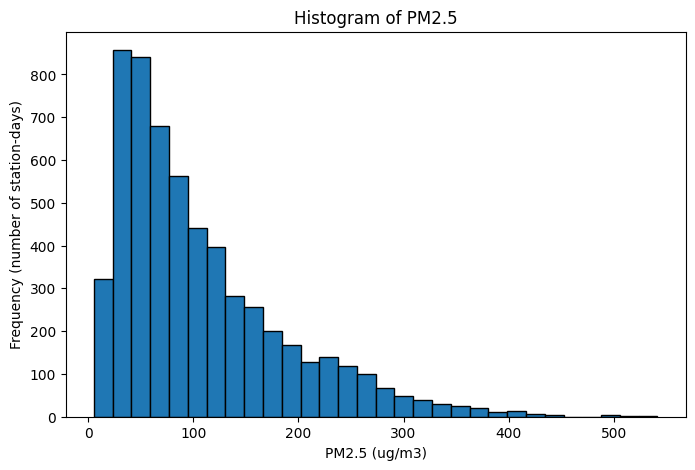

In [17]:
import matplotlib.pyplot as plt

# Drop missing values first, since a histogram cannot place an empty cell in a bin.
pm25_values = df['pm25_ugm3'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(pm25_values, bins=30, edgecolor='black')
plt.title('Histogram of PM2.5')
plt.xlabel('PM2.5 (ug/m3)')
plt.ylabel('Frequency (number of station-days)')
plt.show()

**What this code does.** It removes missing PM2.5 values, then sorts the
remaining values into 30 equal-width bins and draws a bar for each bin whose
height is the number of station-days falling in that bin.

**Why analysts generate this output.** A histogram is the most direct way to see
the *shape* of a variable's distribution — where values cluster, and whether the
shape is even or lopsided — which a table of summary numbers alone cannot show.

**What a histogram shows.** The x-axis holds the variable's value range split
into bins; the y-axis is a count of how many observations landed in each bin.
Tall bars mark value ranges that occur often; short or empty bars mark ranges
that occur rarely or not at all.

**Questions an analyst should ask after viewing it.**

- Does the distribution look roughly symmetric, or does it lean to one side?
- Is there one main peak, or more than one?
- Do the bars taper off gradually, or is there a sudden cutoff?
- Are there bars far away from the main cluster that might be outliers?
- Does the bin width (30 bins) reveal enough detail, or would a different bin
  count show something different?

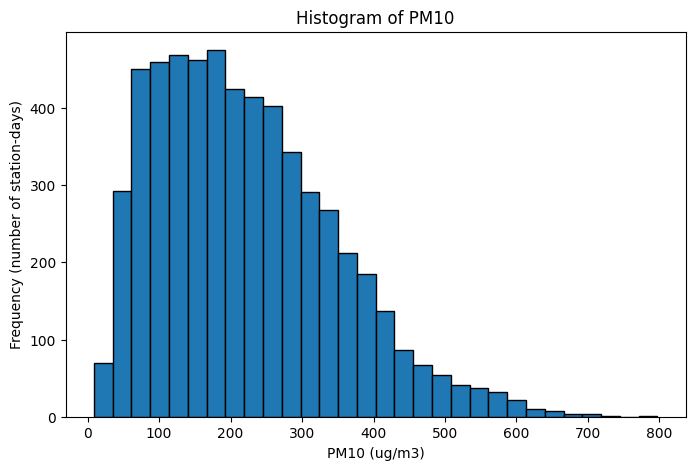

In [18]:
# Drop missing values first, since a histogram cannot place an empty cell in a bin.
pm10_values = df['pm10_ugm3'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(pm10_values, bins=30, edgecolor='black')
plt.title('Histogram of PM10')
plt.xlabel('PM10 (ug/m3)')
plt.ylabel('Frequency (number of station-days)')
plt.show()

**What this code does.** It removes missing PM10 values, then bins the remainder
into 30 equal-width bins and draws a bar showing how many station-days fall in
each bin.

**Why analysts generate this output.** As with PM2.5, this shows the shape of
PM10's distribution directly, which is needed before choosing any further method
of analysis.

**What a histogram shows.** The x-axis is the PM10 value range split into bins;
the y-axis is how many observations fall in each bin.

**Questions an analyst should ask after viewing it.**

- Does the distribution look roughly symmetric, or does it lean to one side?
- Is there one main peak, or more than one?
- Do the bars taper off gradually, or is there a sudden cutoff?
- Are there bars far away from the main cluster that might be outliers?
- Does this shape look similar to, or different from, the PM2.5 histogram above?

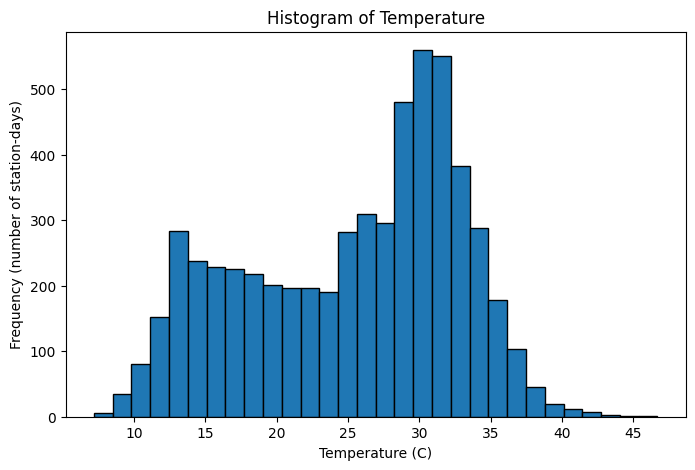

In [19]:
# Drop missing values first, since a histogram cannot place an empty cell in a bin.
temperature_values = df['air_temp_c'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(temperature_values, bins=30, edgecolor='black')
plt.title('Histogram of Temperature')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency (number of station-days)')
plt.show()

**What this code does.** It removes missing Temperature values, then bins the
remainder into 30 equal-width bins and draws a bar showing how many station-days
fall in each bin.

**Why analysts generate this output.** Temperature is a weather variable rather
than a pollutant, so its shape is worth inspecting on its own terms before it is
ever related to anything else.

**What a histogram shows.** The x-axis is the temperature range split into bins;
the y-axis is how many observations fall in each bin.

**Questions an analyst should ask after viewing it.**

- Does the distribution look roughly symmetric, or does it lean to one side?
- Is there one main peak, or more than one?
- Are the bars spread across a wide range, or clustered tightly?
- Are there bars far away from the main cluster that might be outliers?
- Does the shape suggest a natural physical limit at either end?

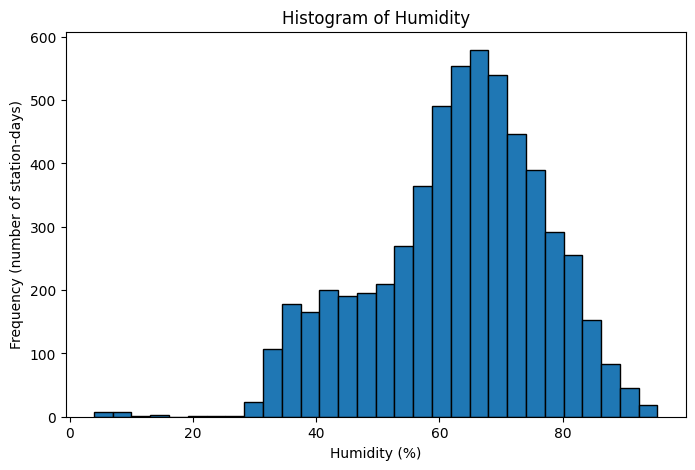

In [20]:
# Drop missing values first, since a histogram cannot place an empty cell in a bin.
humidity_values = df['rh_pct'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(humidity_values, bins=30, edgecolor='black')
plt.title('Histogram of Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency (number of station-days)')
plt.show()

**What this code does.** It removes missing Humidity values, then bins the
remainder into 30 equal-width bins and draws a bar showing how many station-days
fall in each bin.

**Why analysts generate this output.** Humidity is bounded between 0% and 100% by
definition, so seeing where its values sit within that fixed range is informative
on its own.

**What a histogram shows.** The x-axis is the humidity range split into bins; the
y-axis is how many observations fall in each bin.

**Questions an analyst should ask after viewing it.**

- Does the distribution look roughly symmetric, or does it lean to one side?
- Is there one main peak, or more than one?
- Do values bunch up near either the 0% or 100% boundary?
- Are there bars far away from the main cluster that might be outliers?
- Is the spread wide or narrow relative to the full possible 0-100% range?

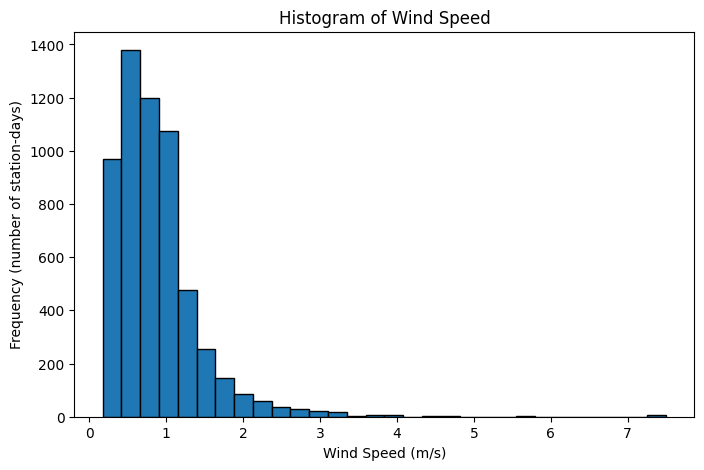

In [21]:
# Drop missing values first, since a histogram cannot place an empty cell in a bin.
wind_speed_values = df['wind_speed_ms'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(wind_speed_values, bins=30, edgecolor='black')
plt.title('Histogram of Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency (number of station-days)')
plt.show()

**What this code does.** It removes missing Wind Speed values, then bins the
remainder into 30 equal-width bins and draws a bar showing how many station-days
fall in each bin.

**Why analysts generate this output.** Wind speed cannot be negative, so its
histogram is expected to start at zero; seeing exactly where its values
concentrate above that floor is useful before any further work.

**What a histogram shows.** The x-axis is the wind speed range split into bins;
the y-axis is how many observations fall in each bin.

**Questions an analyst should ask after viewing it.**

- Does the distribution look roughly symmetric, or does it lean to one side?
- Is there one main peak, or more than one?
- Does wind speed appear to have a natural upper bound in this data?
- Are there bars far away from the main cluster that might be outliers?
- How close to zero do most values sit?

## Box Plots

A box plot is a second, more compact way to view a variable's distribution,
built directly from the same quartiles computed in the Summary Statistics table
above. We draw one box plot for each numerical variable.

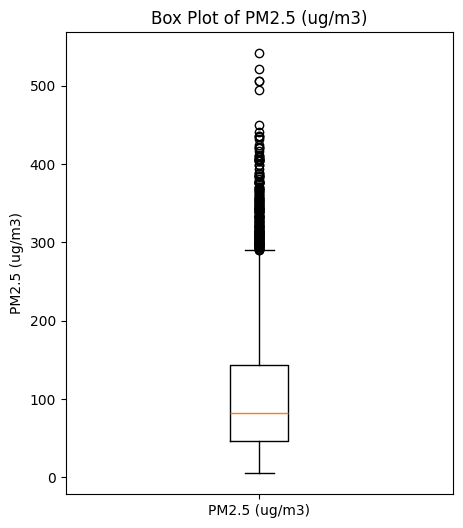

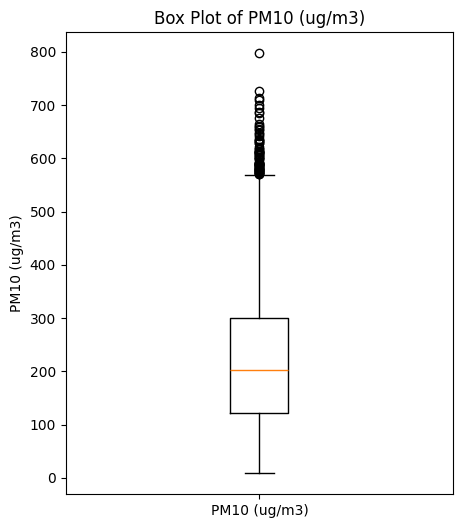

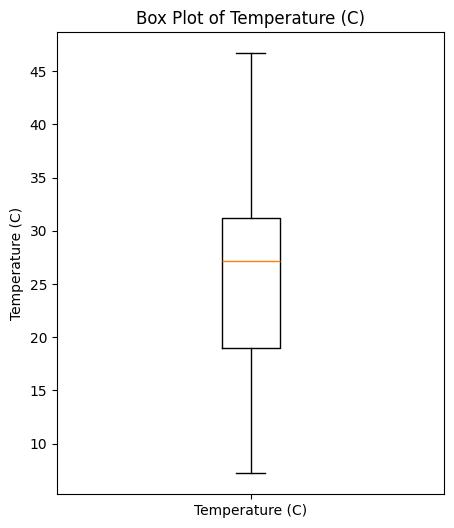

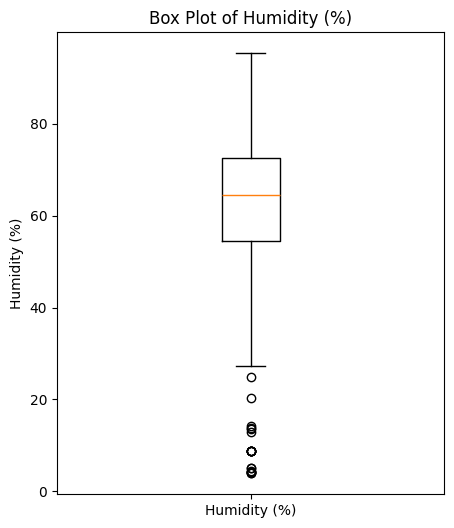

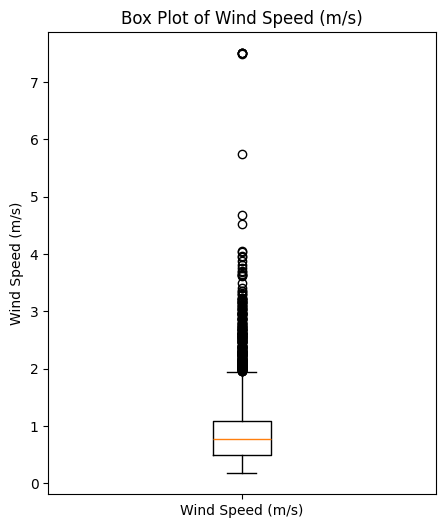

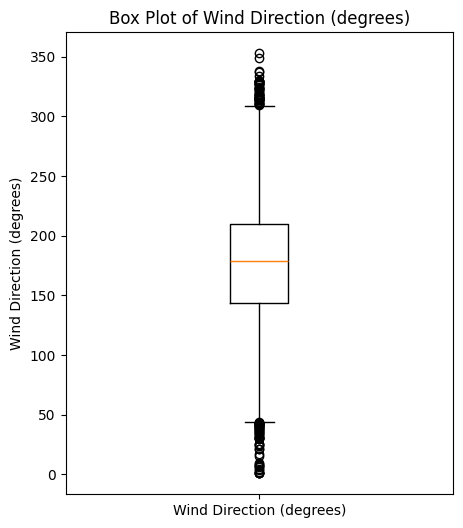

In [22]:
# Reuse the same numeric_columns and variable_labels defined in Summary Statistics.
# One separate box plot is drawn per variable, in its own figure.
for column_name in numeric_columns:
    values = df[column_name].dropna()
    label = variable_labels[column_name]

    plt.figure(figsize=(5, 6))
    plt.boxplot(values)
    plt.title('Box Plot of ' + label)
    plt.ylabel(label)
    plt.xticks([1], [label])
    plt.show()

**What this code does.** For each of the six numerical variables, it drops the
missing values and draws a single box plot in its own figure, labelled with the
variable's name and unit.

**Why analysts generate this output.** A box plot condenses the same five
numbers — minimum, 25th percentile, median, 75th percentile, and maximum — into
one compact picture, making it easy to compare the middle of a distribution
against its extremes at a glance.

**How to read a box plot (not the results themselves).**

- **Median** — the line drawn inside the box marks the middle value of the data.
- **Quartiles** — the bottom and top edges of the box are the 25th percentile and
  75th percentile. The box itself spans the middle 50% of the observations.
- **Interquartile Range (IQR)** — the height of the box (75th percentile minus
  25th percentile). It measures the spread of the middle half of the data,
  ignoring the extremes.
- **Whiskers** — the lines extending above and below the box reach out to the
  furthest points that are still within a standard distance of the box (by
  default, 1.5 times the IQR from each edge).
- **Outliers** — individual points plotted beyond the whiskers. `matplotlib` marks
  each one separately rather than extending the whisker to reach it.

This is only a guide to reading the plot's mechanics — it does not describe what
any of the six variables in this dataset actually show.

## Distribution Checklist

This checklist is **intentionally left blank**. After looking at the histogram
and box plot for each variable above, fill in each row by hand.

| Variable | Appears symmetric? | Appears right skewed? | Appears left skewed? | Contains possible outliers? | Wide spread? | Narrow spread? |
|---|---|---|---|---|---|---|
| PM2.5 (ug/m3) | | | | | | |
| PM10 (ug/m3) | | | | | | |
| Temperature (C) | | | | | | |
| Humidity (%) | | | | | | |
| Wind Speed (m/s) | | | | | | |
| Wind Direction (degrees) | | | | | | |

## Questions Raised

Inspecting the distributions above naturally raises the following questions.
They are recorded here as a to-do list for later sections — **they are not
answered in this Variable Distributions section.**

1. Why is PM2.5 skewed the way it appears in its histogram?
2. Why does PM10 appear different from PM2.5 in shape or spread?
3. Are the outliers seen in the box plots seasonal, or spread throughout the year?
4. Does wind speed have a natural upper bound in this dataset?
5. Why might humidity cluster near one end of its 0-100% range?
6. Do PM2.5 and PM10 show a similar degree of spread, or does one vary far more
   than the other?
7. Is the temperature distribution consistent with two full years of data, or does
   it suggest missing seasonal coverage?
8. Which variable has the widest interquartile range, and what might that imply?
9. Are the outliers flagged in the box plots the same station-days as the
   impossible values found in the Data Quality Assessment section?
10. Would a different number of histogram bins change how skewed a variable
    appears to be?

*End of the Variable Distributions section.*